## Lab 2


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = sns.load_dataset("tips")
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## Task 1

C:\Users\mahad\AppData\Local\Temp\ipykernel_3556\1457307468.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_bill = df.groupby("day")["total_bill"].mean()


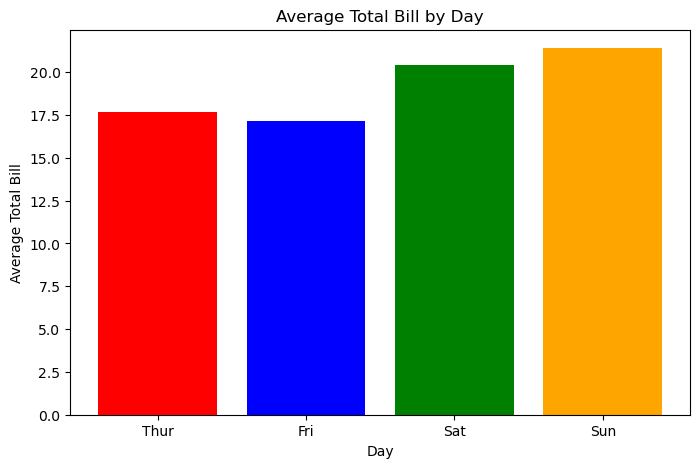

In [11]:
avg_bill = df.groupby("day")["total_bill"].mean()

plt.figure(figsize=(8, 5))
plt.bar(avg_bill.index, avg_bill.values, color=["red", "blue", "green", "orange"])

plt.xlabel("Day")
plt.ylabel("Average Total Bill")
plt.title("Average Total Bill by Day")

plt.show()

## Task 2


C:\Users\mahad\AppData\Local\Temp\ipykernel_3556\1674296530.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="day", palette="Set2")


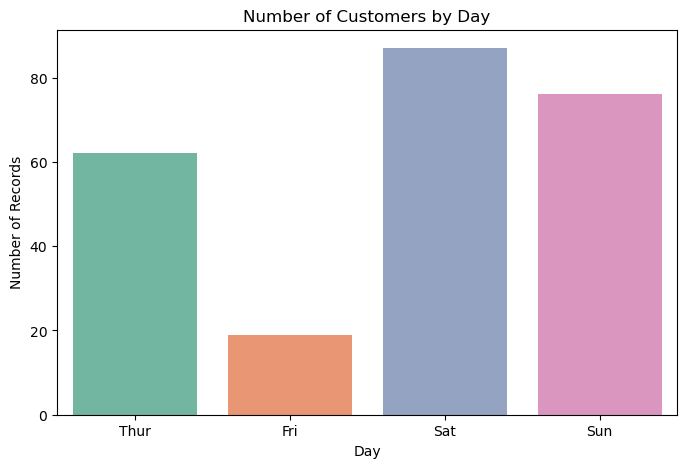

Most common category: Sat
Number of records: 87


In [12]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="day", palette="Set2")

plt.xlabel("Day")
plt.ylabel("Number of Records")
plt.title("Number of Customers by Day")

plt.show()

most_common = df["day"].value_counts().idxmax()
most_common_count = df["day"].value_counts().max()

print("Most common category:", most_common)
print("Number of records:", most_common_count)

## Task 3


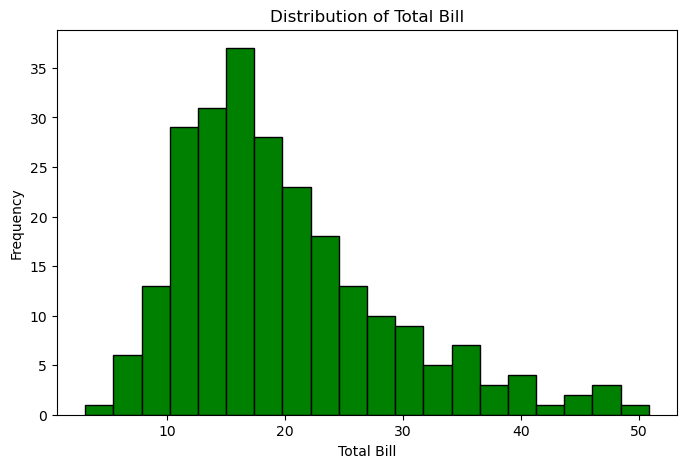

Skewness: 1.1332130376158205
The distribution is right-skewed.


In [16]:
plt.figure(figsize=(8, 5))

plt.hist(df["total_bill"], bins=20, color="green", edgecolor="black")

plt.xlabel("Total Bill")
plt.ylabel("Frequency")
plt.title("Distribution of Total Bill")

plt.show()

# Skewness
skewness = df["total_bill"].skew()

print("Skewness:", skewness)

if skewness > 0:
    print("The distribution is right-skewed.")
elif skewness < 0:
    print("The distribution is left-skewed.")
else:
    print("The distribution is approximately symmetric.")

## Task 4


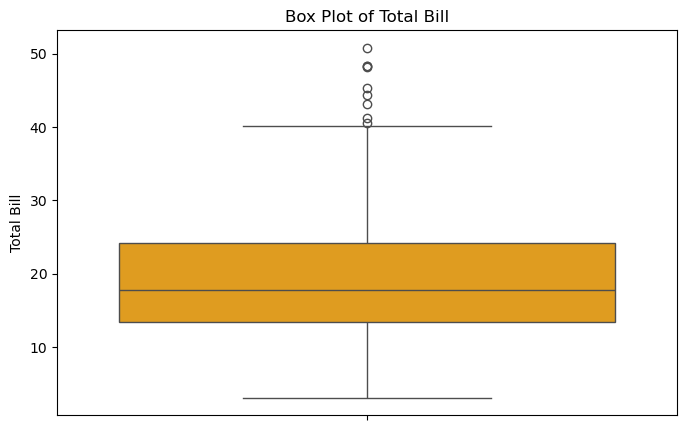

In [25]:
plt.figure(figsize=(8, 5))

sns.boxplot(y=df["total_bill"], color="orange")

plt.ylabel("Total Bill")
plt.title("Box Plot of Total Bill")

plt.show()

## Task 5


In [26]:
Q1 = df["total_bill"].quantile(0.25)
Q3 = df["total_bill"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["total_bill"] < lower) |
    (df["total_bill"] > upper)
]

print("Q1 =", Q1)
print("Q3 =", Q3)
print("IQR =", IQR)
print("Lower Bound =", lower)
print("Upper Bound =", upper)

print("Number of outliers =", len(outliers))

Q1 = 13.3475
Q3 = 24.127499999999998
IQR = 10.779999999999998
Lower Bound = -2.8224999999999945
Upper Bound = 40.29749999999999
Number of outliers = 9


## Task 6

In [21]:
from scipy import stats

df["zscore"] = stats.zscore(df["total_bill"])

outliers_z = df[df["zscore"].abs() > 3]

print("Number of Z-score outliers:", len(outliers_z))

print(outliers_z)

print("IQR outliers:", len(outliers))
print("Z-score outliers:", len(outliers_z))

if len(outliers) == len(outliers_z):
    print("Both methods flagged the same number of outliers.")
else:
    print("The two methods flagged different numbers of outliers.")

print("""
IQR and Z-score may flag different numbers of outliers because they use different statistical approaches. IQR is based on quartiles and is more
robust to extreme values, while Z-score uses the mean and standard deviation and works better when the data is approximately normally distributed.""")

Number of Z-score outliers: 4
     total_bill    tip   sex smoker  day    time  size    zscore
59        48.27   6.73  Male     No  Sat  Dinner     4  3.206166
156       48.17   5.00  Male     No  Sun  Dinner     6  3.194910
170       50.81  10.00  Male    Yes  Sat  Dinner     3  3.492068
212       48.33   9.00  Male     No  Sat  Dinner     4  3.212919
IQR outliers: 9
Z-score outliers: 4
The two methods flagged different numbers of outliers.

IQR and Z-score may flag different numbers of outliers because they use different statistical approaches. IQR is based on quartiles and is more
robust to extreme values, while Z-score uses the mean and standard deviation and works better when the data is approximately normally distributed.


## Task 7


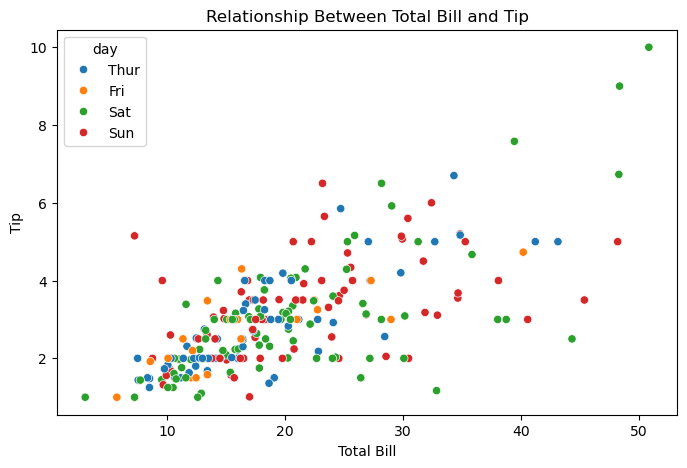

Correlation: 0.6757341092113641
There is a positive relationship.


In [22]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="total_bill",
    y="tip",
    hue="day"
)

plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.title("Relationship Between Total Bill and Tip")

plt.show()

correlation = df["total_bill"].corr(df["tip"])

print("Correlation:", correlation)

if correlation > 0:
    print("There is a positive relationship.")
elif correlation < 0:
    print("There is a negative relationship.")
else:
    print("There is no linear relationship.")

## Task 8


day
Thur    17.682742
Fri     17.151579
Sat     20.441379
Sun     21.410000
Name: total_bill, dtype: float64


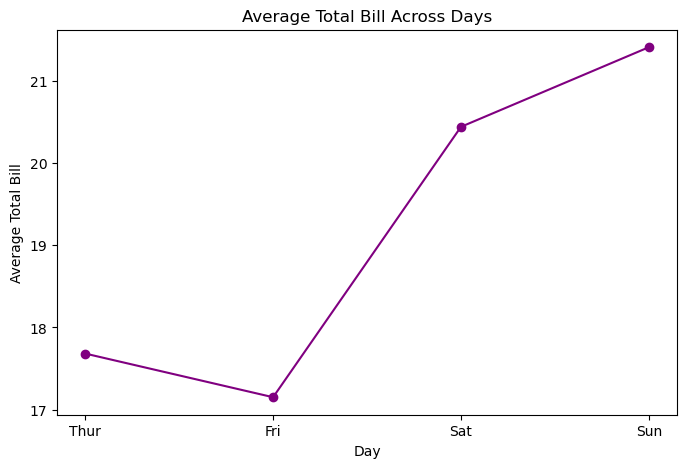

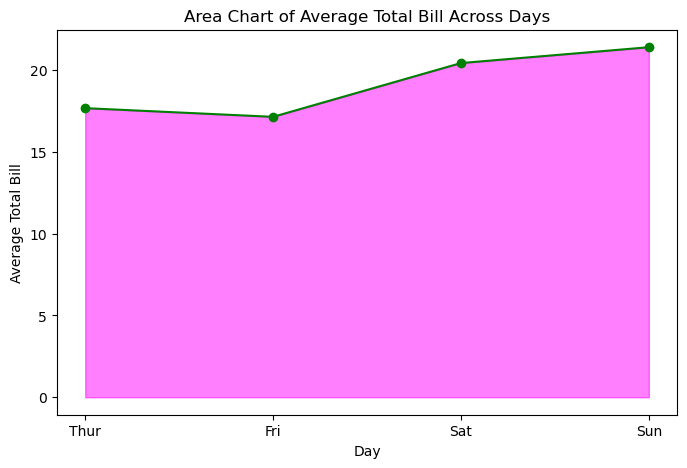

In [29]:
day_order = ["Thur", "Fri", "Sat", "Sun"]

daily_avg = df.groupby("day", observed=True)["total_bill"].mean()

daily_avg = daily_avg.reindex(day_order)

print(daily_avg)

# Line Chart
plt.figure(figsize=(8, 5))

plt.plot(
    daily_avg.index,
    daily_avg.values,
    marker="o",
    color="purple"
)

plt.xlabel("Day")
plt.ylabel("Average Total Bill")
plt.title("Average Total Bill Across Days")

plt.show()

# Area Chart 

plt.figure(figsize=(8, 5))

plt.fill_between(
    range(len(daily_avg)),
    daily_avg.values,
    alpha=0.5,
    color="magenta"
)

plt.plot(
    range(len(daily_avg)),
    daily_avg.values,
    marker="o",
    color="green"
)

plt.xticks(range(len(daily_avg)), daily_avg.index)

plt.xlabel("Day")
plt.ylabel("Average Total Bill")
plt.title("Area Chart of Average Total Bill Across Days")

plt.show()

## Task 9

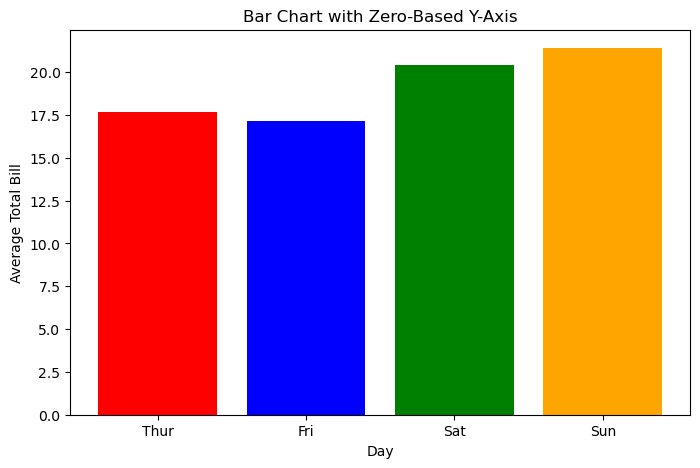

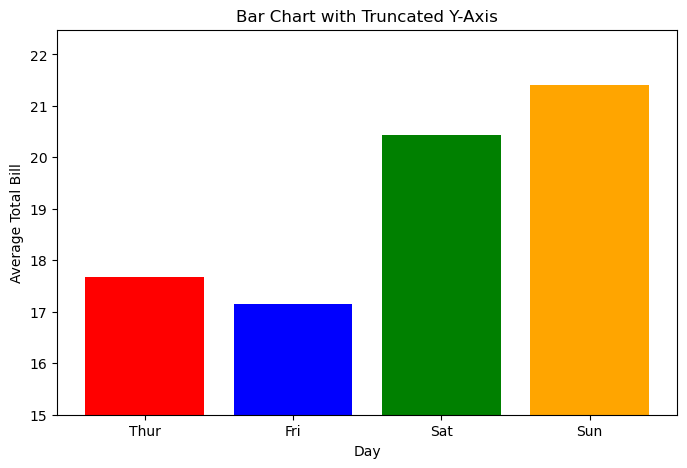

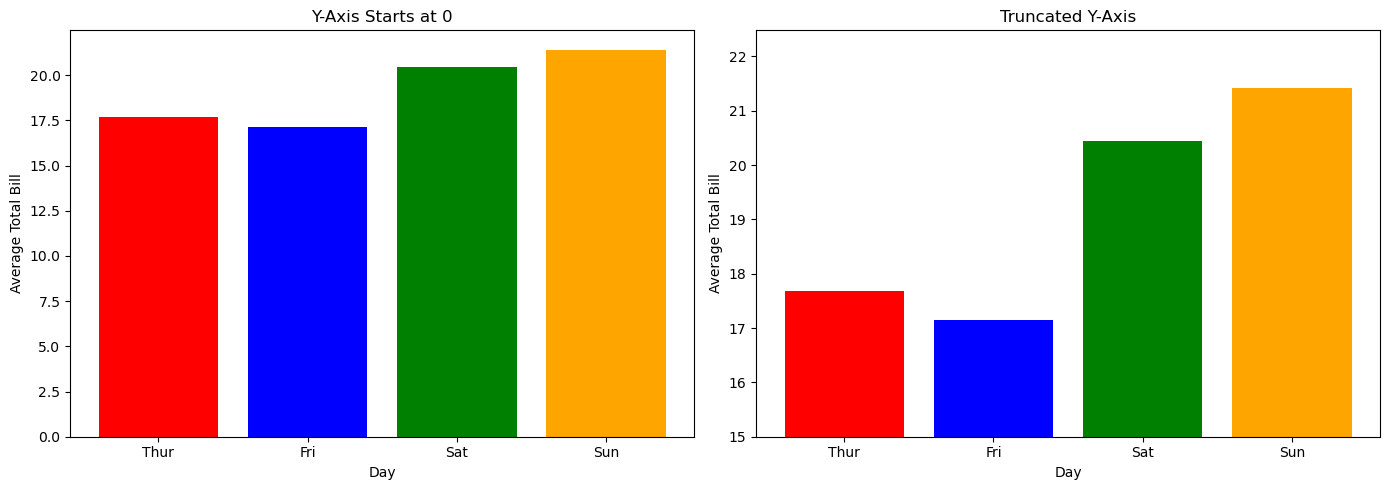

In [32]:
avg_bill = df.groupby("day", observed=True)["total_bill"].mean()
avg_bill = avg_bill.reindex(day_order)

# Correct Bar Chart
plt.figure(figsize=(8, 5))

plt.bar(avg_bill.index, avg_bill.values, color=["red", "blue", "green", "orange"])

plt.xlabel("Day")
plt.ylabel("Average Total Bill")
plt.title("Bar Chart with Zero-Based Y-Axis")

plt.ylim(bottom=0)

plt.show()

# Misleading Bar Chart
plt.figure(figsize=(8, 5))

plt.bar(avg_bill.index, avg_bill.values, color=["red", "blue", "green", "orange"])

plt.xlabel("Day")
plt.ylabel("Average Total Bill")
plt.title("Bar Chart with Truncated Y-Axis")

# Start y-axis above zero
plt.ylim(bottom=15)

plt.show()

# Side-by-Side Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correct chart

axes[0].bar(avg_bill.index, avg_bill.values, color=["red", "blue", "green", "orange"])
axes[0].set_xlabel("Day")
axes[0].set_ylabel("Average Total Bill")
axes[0].set_title("Y-Axis Starts at 0")
axes[0].set_ylim(bottom=0)

# Misleading chart
axes[1].bar(avg_bill.index, avg_bill.values, color=["red", "blue", "green", "orange"])
axes[1].set_xlabel("Day")
axes[1].set_ylabel("Average Total Bill")
axes[1].set_title("Truncated Y-Axis")
axes[1].set_ylim(bottom=15)

plt.tight_layout()
plt.show()